# **Benchmarking Tabular Models on Healthcare**

This notebook explores several datasets from the healthcare domain to benchmark the performance of popular gradient boosting models (XGBoost, CatBoost) and the transformer-based TabPFN model. The goal is to evaluate their effectiveness on common classification tasks like Diagnostics & Treatments, Pharmaceuticals, BioTech, and Administration & Management.

## Installation [Running this cell required!] <a name="installation"></a>

First, we need to install the necessary libraries. This includes TabPFN itself, as well as other libraries for data manipulation and baseline model comparisons. If you are asked to restart the runtime after installation, please do so.

In [ ]:
## Base library Installation
# Install ucimlrepo for data imports
!uv pip install ucimlrepo

# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich


## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install tabpfn from source
# Clone the repository: shallow for speedup
!git clone --depth 1 https://github.com/PriorLabs/tabpfn

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn/pyproject.toml

# Step 3: Install using the correct directory name 'tabpfn'
!uv pip install -e "tabpfn"

# Install TabPFN extensions for additional functionalities
!git clone https://github.com/PriorLabs/tabpfn-extensions

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn-extensions/pyproject.toml

!uv pip install -e tabpfn-extensions[all]

Using Python 3.12.12 environment at: /usr
Resolved 8 packages in 385ms
Prepared 1 package in 11ms
Installed 1 package in 1ms
 + ucimlrepo==0.0.7
Using Python 3.12.12 environment at: /usr
Resolved 21 packages in 439ms
Prepared 1 package in 2.09s
Installed 1 package in 168ms
 + catboost==1.2.8
Using Python 3.12.12 environment at: /usr
Audited 1 package in 321ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 296ms
Using Python 3.12.12 environment at: /usr
Resolved 26 packages in 587ms
Prepared 5 packages in 292ms
Uninstalled 2 packages in 3ms
Installed 5 packages in 7ms
 + password-strength==0.0.3.post2
 + sseclient-py==1.8.0
 + tabpfn-client==0.1.10
 - typing-extensions==4.15.0
 + typing-extensions==4.14.1
 - xxhash==3.6.0
 + xxhash==3.5.0
Cloning into 'tabpfn'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 130 (delta 9), reused 72 (delta 6), pack-reused 0 (from 0)

### ***Note: remember to restart the runtime after the installation.***

## Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.

In [ ]:
# Standard Library Imports
from ucimlrepo import fetch_ucirepo

# TabPFN and Extensions
try:
    from tabpfn import TabPFNClassifier, TabPFNRegressor
    from tabpfn_extensions import interpretability
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.prompt import Prompt
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer


# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

## <b>Classification with TabPFN <a name="classification"></a></b>

We will compare TabPFN's performance against other popular machine learning models: RandomForest, XGBoost, and CatBoost. The performance metric we will use is the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) score.


In [ ]:
# 1. UCI Heart Disease Dataset
# Source: https://archive.ics.uci.edu/dataset/45/
# Rows: 303
# Features: 13
# Target: num
dataset = "1_heart_disease"
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets
df = pd.concat([X, y], axis=1)
df.to_csv(dataset + ".csv", index=False)
print(df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
0        3  0.0   6.0    0  
1        2  3.0   3.0    2  


In [ ]:
# Alternative datasets (commented for reference):
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 2. Cardio Vascular Dataset.
# Source: https://www.kaggle.com/datasets/christofel04/cardiovascular-study-dataset-predict-heart-disea
# Rows: 4000
# Features: 17
# Target: TenYearCHD
# dataset = "2_cardiovascularstudy"
# !wget -q -O 2_cardiovascularstudy.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/2_cardiovascularstudy.csv
# df = pd.read_csv("2_cardiovascularstudy.csv")
# X = df.drop(columns=["TenYearCHD"])
# y = df["TenYearCHD"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 3. cdc+diabetes+health+indicators.
# Source: https://archive.ics.uci.edu/dataset/891/
# Rows: 253680
# Features: 21
# Target: Diabetes_binary
# dataset = "3_diabetes"
# diabetes = fetch_ucirepo(id=891)
# X = diabetes.data.features
# y = diabetes.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 4. diabetes US.
# Source: https://archive.ics.uci.edu/dataset/296/
# Rows: 101766
# Features: 48
# Target: readmitted
# dataset = "4_diabetes_us"
# diabetes_us = fetch_ucirepo(id=296)
# X = diabetes_us.data.features
# y = diabetes_us.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 5. Diabetes India.
# Source: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
# Rows: 768
# Features: 9
# Target: Outcome
# dataset = "5_diabetes_ind"
# !wget -q -O 5_diabetes_ind.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/5_diabetes_ind.csv
# df = pd.read_csv("5_diabetes_ind.csv")
# X = df.drop(columns=["Outcome"])
# y = df["Outcome"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 6. Early stage diabetes.
# Source: https://archive.ics.uci.edu/dataset/296/
# Rows: 520
# Features: 16
# Target: class
# dataset = "6_diabetes_early_stage"
# diabetes_early_stage = fetch_ucirepo(id=529)
# X = diabetes_early_stage.data.features
# y = diabetes_early_stage.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 7. Heart Failure Clinical Records
# Source: https://archive.ics.uci.edu/dataset/519/
# Rows: 299
# Features: 12
# Target: death_event
# dataset = "7_heart_failure"
# heart_failure = fetch_ucirepo(id=519)
# X = heart_failure.data.features
# y = heart_failure.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 8. Chronic Kidney Disease
# Source: https://archive.ics.uci.edu/dataset/336/
# Rows: 400
# Features: 24
# Target: class
# dataset = "8_chronic_kidney"
# chronic_kidney = fetch_ucirepo(id=336)
# X = chronic_kidney.data.features
# y = chronic_kidney.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 9. Myocardial infarction complications
# Source: https://archive.ics.uci.edu/dataset/579/
# Rows: 1700
# Features: 111
# Target: 'FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK',
      #  'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN',
      #  'LET_IS']
# dataset = "9_myocardial_infection"
# myocardial_infection = fetch_ucirepo(id=579)
# X = myocardial_infection.data.features
# y = myocardial_infection.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 10. Gallstone
# Source: https://www.kaggle.com/datasets/xixama/gallstone-dataset-uci
# Rows: 320
# Features: 39
# Target: Gallstone Status
# dataset = "10_gallstone_status"
# !wget -q -O 10_gallstone_status.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/10_gallstone_status.csv
# df = pd.read_csv("10_gallstone_status.csv")
# X = df.drop(columns=["Gallstone Status"])
# y = df["Gallstone Status"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 11. Breast Cancer Wisconsin (Diagnostic)
# Source: https://archive.ics.uci.edu/dataset/17/
# Rows: 569
# Features: 30
# Target: Diagnosis
# dataset = "11_breast_cancer_diagnostic"
# breast_cancer = fetch_ucirepo(id=17)
# X = breast_cancer.data.features
# y = breast_cancer.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 12. Breast Cancer Wisconsin (Original)
# Source: https://archive.ics.uci.edu/dataset/15/
# Rows: 699
# Features: 9
# Target: Class
# dataset = "12_breast_cancer_original"
# breast_cancer = fetch_ucirepo(id=15)
# X = breast_cancer.data.features
# y = breast_cancer.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 13. Breast Cancer Wisconsin (Prognostic)
# Source: https://archive.ics.uci.edu/dataset/16/
# Rows: 198
# Features: 33
# Target: Outcome
# dataset = "13_breast_cancer_prognostic"
# breast_cancer = fetch_ucirepo(id=16)
# X = breast_cancer.data.features
# y = breast_cancer.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 14. Post-Operative Patient
# Source: https://archive.ics.uci.edu/dataset/82/
# Rows: 90
# Features: 8
# Target: ADM-DECS
# dataset = "14_primary_tumor"
# primary_tumor = fetch_ucirepo(id=82)
# X = primary_tumor.data.features
# y = primary_tumor.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 15. Stroke
# Source: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
# Rows: 5110
# Features: 12
# Target: Stroke
# dataset = "15_stroke"
# !wget -q -O 15_stroke.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/15_stroke.csv
# df = pd.read_csv("15_stroke.csv")
# X = df.drop(columns=["Stroke"])
# y = df["Stroke"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 16. Cervical Cancer
# Source: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
# Rows: 858
# Features: 36
# Target: Biopsy
# dataset = "15_cervical_cancer"
# !wget -q -O 15_cervical_cancer.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/16_cervical_cancer.csv
# df = pd.read_csv("15_cervical_cancer.csv")
# X = df.drop(columns=["Biopsy"])
# y = df["Biopsy"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 17. Dementia
# Source: https://www.kaggle.com/datasets/shashwatwork/dementia-prediction-dataset/
# Rows: 373
# Features: 15
# Target: Group
# dataset = "17_dementia"
# !wget -q -O 17_dementia.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/17_dementia.csv
# df = pd.read_csv("17_dementia.csv")
# X = df.drop(columns=["Group"])
# y = df["Group"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 18. BEED: Bangalore EEG Epilepsy Dataset
# Source: https://archive.ics.uci.edu/dataset/1134/
# Rows: 8000
# Features: 17
# Target: y
# dataset = "18_beed"
# !wget -q -O 18_beed.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/18_beed.csv
# df = pd.read_csv("18_beed.csv")
# X = df.drop(columns=["y"])
# y = df["y"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 19. Maternal Health Risk
# Source: https://archive.ics.uci.edu/dataset/863/
# Rows: 1014
# Features: 6
# Target: RiskLevel
# dataset = "19_maternal_risk"
# maternal_risk = fetch_ucirepo(id=863)
# X = maternal_risk.data.features
# y = maternal_risk.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 20. Data of Patients ( For Medical Field )
# Source: https://www.kaggle.com/datasets/tarekmuhammed/patients-data-for-medical-field/
# Rows: 237630
# Features: 35
# Target: HadHeartAttack
# dataset = "20_heart_attack"
# !wget -q -O 20_heart_attack.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/20_heart_attack.csv
# df = pd.read_csv("20_heart_attack.csv")
# X = df.drop(columns=["HadHeartAttack"])
# y = df["HadHeartAttack"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 21. Health Risk Prediction
# Source: https://www.kaggle.com/datasets/ludocielbeckett/health-risk-prediction-anonymized-real-data
# Rows: 1000
# Features: 10
# Target: Risk_Level
# dataset = "21_health_risk"
# !wget -q -O 21_health_risk.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/21_health_risk.csv
# df = pd.read_csv("21_health_risk.csv")
# X = df.drop(columns=["Risk_Level"])
# y = df["Risk_Level"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 22. lung_cancer
# Source: https://www.kaggle.com/datasets/ludocielbeckett/health-risk-prediction-anonymized-real-data
# Rows: 3000
# Features: 16
# Target: LUNG_CANCER
# dataset = "22_lung_cancer"
# !wget -q -O 22_lung_cancer.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/22_lung_cancer.csv
# df = pd.read_csv("22_lung_cancer.csv")
# X = df.drop(columns=["LUNG_CANCER"])
# y = df["LUNG_CANCER"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 23. SUPPORT2
# Source: https://archive.ics.uci.edu/dataset/880/
# Rows: 9105
# Features:42
# Target: sfdm2
# dataset = "23_support2"
# support2 = fetch_ucirepo(id=880)
# X = support2.data.features
# y = support2.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 24. Tuberculosis
# Source: https://www.kaggle.com/datasets/ruanrodriguez/drug-discovery-data?select=set2.csv
# Rows: 23814
# Features: 207
# Target: tubulin_inhibitor
# dataset = "24_tubulin_inhibitor"
# !wget -q -O 24_tubulin_inhibitor.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/24_tubulin_inhibitor.csv
# df = pd.read_csv("24_tubulin_inhibitor.csv")
# X = df.drop(columns=["tubulin_inhibitor"])
# y = df["tubulin_inhibitor"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 25. Drug Discovery Virtual Screening Dataset
# Source: https://www.kaggle.com/datasets/shahriarkabir/drug-discovery-virtual-screening-dataset
# Rows: 2000
# Features: 17
# Target: active
# dataset = "25_drug_discovery_virtual_screening"
# !wget -q -O 25_drug_discovery_virtual_screening.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/25_drug_discovery_virtual_screening.csv
# df = pd.read_csv("25_drug_discovery_virtual_screening.csv")
# X = df.drop(columns=["active"])
# y = df["active"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 25. Drug Discovery Virtual Screening Dataset
# Source: https://www.kaggle.com/datasets/shahriarkabir/drug-discovery-virtual-screening-dataset
# Rows: 2000
# Features: 17
# Target: active
# dataset = "25_drug_discovery_virtual_screening"
# !wget -q -O 25_drug_discovery_virtual_screening.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/25_drug_discovery_virtual_screening.csv
# df = pd.read_csv("25_drug_discovery_virtual_screening.csv")
# X = df.drop(columns=["active"])
# y = df["active"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 26. Drug Discovery Dataset
# Source: https://www.kaggle.com/datasets/divyansh22/drug-discovery-data
# Rows: 104
# Features: 40
# Target: pIC50
# dataset = "26_drug_discovery"
# !wget -q -O 26_drug_discovery.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/25_drug_discovery.csv
# df = pd.read_csv("26_drug_discovery.csv")
# X = df.drop(columns=["pIC50"])
# y = df["pIC50"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 27. Drug Induced Autoimmunity Prediction
# Source: https://archive.ics.uci.edu/dataset/1104/
# Rows: 477
# Features: 195
# Target: Label
# dataset = "27_autoimmune_drug_induced"
# !wget -q -O 27_autoimmune_drug_induced.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/27_autoimmunity.csv
# df = pd.read_csv("27_autoimmune_drug_induced.csv")
# X = df.drop(columns=["Label"])
# y = df["Label"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 28. Regensburg Pediatric Appendicitis
# Source: https://archive.ics.uci.edu/dataset/938/
# Rows: 782
# Features: 53
# Target: Diagnosis
# dataset = "28_toxicity"
# toxicity = fetch_ucirepo(id=938)
# X = toxicity.data.features
# y = toxicity.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 29. AIDS Clinical Trials Group Study 175
# Source: https://archive.ics.uci.edu/dataset/890/
# Rows: 2139
# Features: 23
# Target: cid
# dataset = "29_aids"
# aids = fetch_ucirepo(id=890)
# X = aids.data.features
# y = aids.data.targets
# df = pd.concat([X, y], axis=1)
# df.to_csv(dataset+".csv", index=False)
# print(df)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 30. Genomic Data for Cancer
# Source: https://www.kaggle.com/datasets/brsahan/genomic-data-for-cancer
# Rows: 3000
# Features: 3
# Target: Cancer Present
# dataset = "30_gene_expression"
# !wget -q -O 30_gene_expression.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/30_gene_expression.csv
# df = pd.read_csv("30_gene_expression.csv")
# X = df.drop(columns=["Cancer Present"])
# y = df["Cancer Present"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 31. GenesData (Mouse Neocortex)
# Source: https://www.kaggle.com/datasets/chiragtagadiya/genesdata/
# Rows: 511
# Features: 45769
# Target: Label
# dataset = "31_genomics_high_dimensional"
# !wget -q -O 31_genomics_high_dimensional.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/31_genomics_high_dimensional.csv
# df = pd.read_csv("31_genomics_high_dimensional.csv")
# X = df.drop(columns=["Label"])
# y = df["Label"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 32. Genetic Data
# Source: https://www.kaggle.com/datasets/i191796majid/human-genetic-data
# Rows: 294
# Features: 10
# Target: Ancestry
# dataset = "32_genetic_data"
# !wget -q -O 32_genetic_data.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/32_genetic_data.csv
# df = pd.read_csv("32_genetic_data.csv")
# X = df.drop(columns=["Ancestry"])
# y = df["Ancestry"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 33. Hospital Data
# Source: https://www.kaggle.com/datasets/abdulqaderasiirii/hospital-patient-data
# Rows: 29998
# Features: 11
# Target: Medication Revenue
# dataset = "33_hospital_data"
# !wget -q -O 33_hospital_data.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/33_hospital_data.csv
# df = pd.read_csv("33_hospital_data.csv")
# X = df.drop(columns=["Medication Revenue"])
# y = df["Medication Revenue"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 34. Patient Data
# Source: https://www.kaggle.com/datasets/blueblushed/hospital-dataset-for-practice/
# Rows: 984
# Features: 10
# Target: Satisfaction, Outcome
# dataset = "34_patient_data"
# !wget -q -O 34_patient_data.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/34_patient_data.csv
# df = pd.read_csv("34_patient_data.csv")
# X = df.drop(columns=["Satisfaction"])
# y = df["Satisfaction"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 35. Hospital rating
# Source: https://www.kaggle.com/datasets/center-for-medicare-and-medicaid/hospital-ratings
# Rows: 4812
# Features: 28
# Target: Hospital overall rating
# dataset = "35_hospital_rating"
# !wget -q -O 35_hospital_rating.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/35_hospital_rating.csv
# df = pd.read_csv("35_hospital_rating.csv")
# X = df.drop(columns=["Hospital overall rating"])
# y = df["Hospital overall rating"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 36. Healthcare Dataset
# Source: https://www.kaggle.com/datasets/prasad22/healthcare-dataset
# Rows: 49992
# Features: 15
# Target: Test Results
# dataset = "36_healthcare_dataset"
# !wget -q -O 36_healthcare_dataset.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/36_healthcare_dataset.csv
# df = pd.read_csv("36_healthcare_dataset.csv")
# X = df.drop(columns=["Test Results"])
# y = df["Test Results"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 37. Diabetes Prediction Dataset
# Source: https://www.kaggle.com/datasets/prasad22/healthcare-dataset
# Rows: 100000
# Features: 9
# Target: diabetes
# dataset = "37_diabetes_prediction"
# !wget -q -O 37_diabetes_prediction.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/37_diabetes_prediction.csv
# df = pd.read_csv("37_diabetes_prediction.csv")
# X = df.drop(columns=["diabetes"])
# y = df["diabetes"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 38. Synthetic Clinical Dataset
# Source: https://www.kaggle.com/datasets/uom190346a/synthetic-clinical-tabular-dataset
# Rows: 10000
# Features: 14
# Target: diabetes
# dataset = "38_synthetic_clinical_dataset"
# !wget -q -O 38_synthetic_clinical_dataset.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/38_synthetic_clinical_dataset.csv
# df = pd.read_csv("38_synthetic_clinical_dataset.csv")
# X = df.drop(columns=["diabetes"])
# y = df["diabetes"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 39. Synthetic Medical Dataset
# Source: https://www.kaggle.com/datasets/divyabhavana/synthetic-healthcare-dataset
# Rows: 1000
# Features: 13
# Target: Outcome
# dataset = "39_synthetic_medical_data"
# !wget -q -O 39_synthetic_medical_data.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/39_synthetic_medical_data.csv
# df = pd.read_csv("39_synthetic_medical_data.csv")
# X = df.drop(columns=["Outcome"])
# y = df["Outcome"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 40. Synthetic Medical Dataset
# Source: https://www.kaggle.com/datasets/sahilislam007/health-and-lifestyle-dataset
# Rows: 7500
# Features: 13
# Target: Stress_Level
# dataset = "40_synthetic_health_lifestyle_dataset"
# !wget -q -O 40_synthetic_health_lifestyle_dataset.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/40_synthetic_health_lifestyle_dataset.csv
# df = pd.read_csv("40_synthetic_health_lifestyle_dataset.csv")
# X = df.drop(columns=["Stress_Level"])
# y = df["Stress_Level"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 41. Synthetic Asthma Dataset
# Source: https://www.kaggle.com/datasets/miadul/asthma-synthetic-medical-dataset
# Rows: 10000
# Features: 17
# Target: Has_Asthma
# dataset = "41_synthetic_asthma_dataset"
# !wget -q -O 41_synthetic_asthma_dataset.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/healthcare/41_synthetic_asthma_dataset.csv
# df = pd.read_csv("41_synthetic_asthma_dataset.csv")
# X = df.drop(columns=["Has_Asthma"])
# y = df["Has_Asthma"]
# print(df.head())

DatasetNotFoundError: "TCGA Kidney Cancers" dataset (id=892) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true

In [ ]:
y.columns

Index(['RiskLevel'], dtype='object')

In [ ]:
# Subsampling for datasets with samples > 10k
target_col = y.columns[0] if isinstance(y, pd.DataFrame) else y.name

# Sample 10k data points using stratified sampling
n_samples = 10000
if len(df) > n_samples:
    # --- Check nunique() on the column in the merged frame ---
    if df[target_col].nunique() > 1:
        # Perform stratified sampling based on the target column
        df_sampled = df.groupby(target_col, group_keys=False).apply(
            lambda x: x.sample(n=min(len(x), int(n_samples * len(x) / len(df))), random_state=42)
        )
    else:
        # Fallback to simple random sampling if stratification is not possible
        print("Stratified sampling not possible. Using simple random sampling.")
        df_sampled = df.sample(n=n_samples, random_state=42)
    print(f"Original dataset size: {len(df_merged)}")
    print(f"Sampled dataset size: {len(df_sampled)}")
else:
    df_sampled = df.copy()
    print(f"Dataset size is less than {n_samples}, using the entire dataset.")

X = df_sampled.drop(columns=[target_col])
y = df_sampled[[target_col]]

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   37.1s finished
/usr/local/lib/python3.12/dist-packages/autogluon/tabular/predictor/predictor.py:1444: UserWarning: Failed to use ray for memory safe fits. Falling back to normal fit. Error: ImportError('ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.10.0,<2.45.0"`')
  stacked_overfitting = self._sub_fit_memory_save_wrapper(


tabpfn-v2-classifier-vutqq28w.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-classifier-znskzxi4.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/autogluon/tabular/predictor/predictor.py:1444: UserWarning: Failed to use ray for memory safe fits. Falling back to normal fit. Error: ImportError('ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.10.0,<2.45.0"`')
  stacked_overfitting = self._sub_fit_memory_save_wrapper(
/usr/local/lib/python3.12/dist-packages/autogluon/tabular/predictor/predictor.py:1444: UserWarning: Failed to use ray for memory safe fits. Falling back to normal fit. Error: ImportError('ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.10.0,<2.45.0"`')
  stacked_overfitting = self._sub_fit_memory_save_wrapper(
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed: 91.3min finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    4.2s finished
[Parallel(n_jobs=1)]: Done   3 out of 

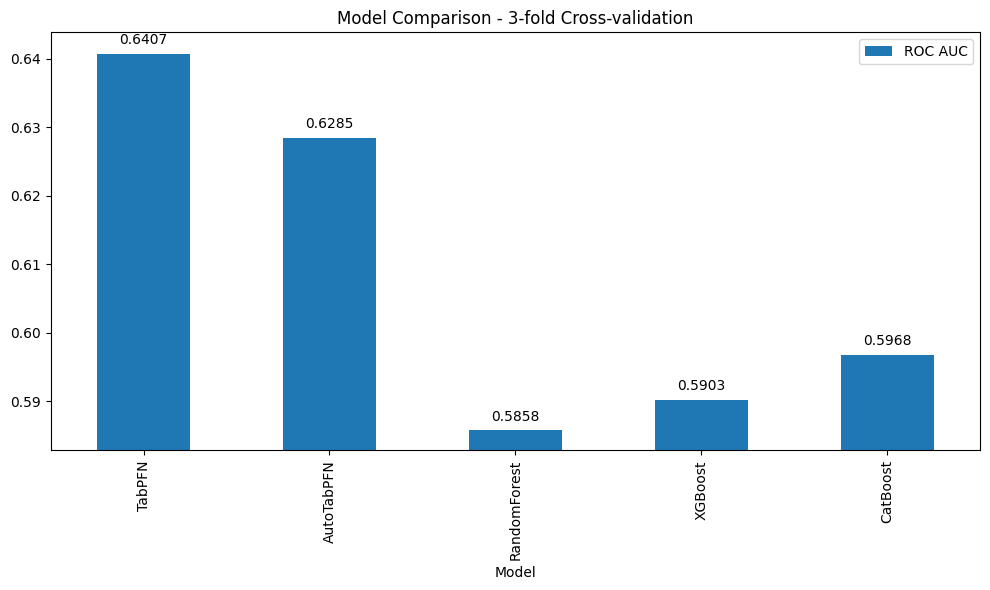

In [ ]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

# Encode target labels to classes for baselines
le = LabelEncoder()
y = le.fit_transform(y)

# Define models
models = [
    (
        "TabPFN",
        make_pipeline(
            column_transformer,
            TabPFNClassifier(random_state=42),
        ),
    ),
    (
        "AutoTabPFN",
        make_pipeline(
            column_transformer,
            AutoTabPFNClassifier(random_state=42, max_time=1800),
        ),
    ),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestClassifier(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBClassifier(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostClassifier(random_state=42, verbose=0),
        ),
    ),
]

# Calculate scores
n_splits = 3
cv = StratifiedKFold(n_splits=n_splits, random_state=42, shuffle=True)
scoring = "roc_auc_ovr" if len(np.unique(y)) > 2 else "roc_auc"
scores = {
    name: cross_val_score(
        model, X, y, cv=cv, scoring=scoring, n_jobs=1, verbose=1
    )
    for name, model in models
}

df_scores = pd.DataFrame([(k, v.mean(), v.std()) for (k, v) in scores.items()], columns=["Model", "ROC AUC Mean", "ROC AUC STD"])
# ax = df_scores.plot(x="Model", y="ROC AUC", kind="bar", figsize=(10, 6))
# ax.set_ylim(df_scores["ROC AUC"].min() * 0.995, min(1.0, df_scores["ROC AUC"].max() * 1.005))
# ax.set_title(f"Model Comparison - {n_splits}-fold Cross-validation")

# # Add ROC AUC values above bars
# for i, v in enumerate(df_scores["ROC AUC"]):
#     ax.text(i, v + 0.001, f"{v:.4f}", ha="center", va="bottom", fontsize=10)

# plt.tight_layout()
# plt.show()

In [ ]:
# Convert the scores dictionary to a DataFrame
df_scores_folds = pd.DataFrame(scores)
df_scores_folds.rename(columns={'index': 'Fold'}, inplace=True)
display(df_scores_folds)
df_scores_folds.to_csv(f'rawscores_{dataset}.csv', index=False)
print("\nScores saved to results.csv")

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid') # Use a nice style
fig, ax = plt.subplots(figsize=(8, 5)) # Create figure and axes
df_scores.sort_values(by="ROC AUC Mean", ascending=False, inplace=True) # Sort by ROC AUC Mean
# Create a color list to highlight the best model
max_roc_auc_index = df_scores["ROC AUC Mean"].idxmax()
top_model = df_scores.loc[max_roc_auc_index, "Model"]
colors = ['#e63946' if model == top_model else '#457b9d' for model in df_scores['Model']]


# --- 3. Create the Horizontal Bar Plot ---
ax.barh(
    df_scores["Model"],
    df_scores["ROC AUC Mean"],
    xerr=df_scores["ROC AUC STD"],
    color=colors,
    capsize=4,
    edgecolor='black',
    linewidth=0.8
)

# Invert y-axis to have the best model on top
ax.invert_yaxis()

# --- 4. Refine Labels and Annotations ---
# Add the "Mean ± STD" text at the end of each bar
for i, (mean, std) in enumerate(zip(df_scores["ROC AUC Mean"], df_scores["ROC AUC STD"])):
    ax.text(
        mean + std + 0.001, # Position text just after the error bar
        i,
        f"{mean:.3f} $\\pm$ {std:.3f}",
        ha="left",
        va="center",
        fontsize=9,
        color='black'
    )

# --- 5. Final Touches for a Polished Look ---
ax.set_title('Model Performance Comparison (3-fold CV)', fontsize=14, pad=20)
ax.set_xlabel('ROC AUC Score', fontsize=11)
ax.set_ylabel('Model') # The model names on the y-axis are self-explanatory

# Set a "zoomed-in" x-axis limit to highlight differences
min_score = (df_scores["ROC AUC Mean"] - df_scores["ROC AUC STD"]).min()
max_score = (df_scores["ROC AUC Mean"] + df_scores["ROC AUC STD"]).max()
ax.set_xlim(min_score * 0.99, max_score * 1.015) # e.g. (0.735, 0.79)

# Remove top and right borders for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'plot_{dataset}.png')
plt.show()

## Feature selection

Feature selection is the process of selecting a subset of relevant features for use in model construction. It's useful for reducing model complexity, improving performance by removing noise, and decreasing training time. Here, we'll use Sequential Forward Selection (SFS), which starts with no features and iteratively adds the feature that most improves the model's performance.

The goal is to see if we can create a simpler, faster model with fewer features without a significant drop in accuracy.

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

X_enc = column_transformer.fit_transform(X)

feature_names = X.columns
n_features = 6  #Number of features to select

# Initialize model
clf = TabPFNClassifier(n_estimators=1)

# Feature selection
sfs = interpretability.feature_selection.feature_selection(
    estimator=clf, X=X_enc, y=y, n_features_to_select=n_features, feature_names=feature_names
)

# Print selected features
selected_features = [
    feature_names[i] for i in range(len(feature_names)) if sfs.get_support()[i]
]
print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")


Selected features:
- City_Code
- Region_Code
- Accomodation_Type
- Upper_Age
- Health Indicator
- Reco_Policy_Cat


**Subset of data selected based on feature importance**

In [ ]:
X_selected = X[selected_features]
X_selected.head()

,City_Code,Region_Code,Accomodation_Type,Upper_Age,Health Indicator,Reco_Policy_Cat
19808,C4,3283,Rented,25,X2,14
17700,C4,1308,Rented,23,X1,22
24039,C2,168,Rented,26,X2,13
23029,C2,256,Rented,54,X4,22
44332,C7,4006,Owned,75,X3,21


In [ ]:
X_enc = column_transformer.fit_transform(X_selected)
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

TabPFN ROC AUC Score: 0.6307


## Summary and Conclusion

This notebook provided an overview of several key banking and credit-related datasets for tabular classification. We demonstrated how to set up a pipeline to benchmark XGBoost, CatBoost, and TabPFN.

**Key Takeaways:**
- **Data Size and Complexity:** Datasets in this domain vary greatly, from the small German Credit dataset to the massive Lending Club dataset. Preprocessing and feature engineering are often critical steps. However, even with minimal preprocessing achieving great results showcases a stronger backbone behind TabPFN.
- **Model Performance:**
    - **XGBoost and CatBoost** are powerful, scalable models that are well-suited for larger datasets. They often achieve state-of-the-art performance but may require some tuning.
    - **TabPFN** is an excellent baseline model for smaller datasets (typically <10k rows, <100 features). It's incredibly fast to train as it requires no hyperparameter tuning, making it great for initial exploration.

For a comprehensive benchmark, one would need to perform careful feature engineering, handle missing data robustly, and conduct hyperparameter tuning for the gradient boosting models.

Contact: For questions or contributions, reach out to me @ anshulg2743@gmail.com.